<a href="https://colab.research.google.com/github/Kabilash01/Semester6/blob/main/Module2_GML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy
!pip install langdetect
!pip install fasttext
!pip install spacy
!pip install networkx
!pip install matplotlib
!pip install gensim
!pip install scipy
!pip install pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 17.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=87a5e13ed850146b298a6533cf72131991ca0669fb1bf228f27a4cc3e4086ecb
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 4.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.2-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.2-py3-none-any.whl (310 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4647420 sha256=1654ab5a85ace80f33b262292976befc264b8b5d83625e7ce618865b86420166
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1

In [ ]:
import nltk

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import nltk

In [ ]:
%matplotlib inline
from matplotlib import pyplot as plt

In [ ]:
nltk.download('reuters')

[nltk_data] Downloading package reuters to /root/nltk_data...


True

In [ ]:
from nltk.corpus import reuters

In [ ]:
corpus = pd.DataFrame([
    {"id": _id,
     "clean_text": reuters.raw(_id).replace("\n", ""),
     "label": reuters.categories(_id)}
    for _id in reuters.fileids()
]).set_index("id")

In [ ]:
corpus[corpus.index.str.startswith('training/')].head()

,clean_text,label
id,,
training/1,BAHIA COCOA REVIEW Showers continued througho...,[cocoa]
training/10,COMPUTER TERMINAL SYSTEMS &lt;CPML> COMPLETES ...,[acq]
training/100,N.Z. TRADING BANK DEPOSIT GROWTH RISES SLIGHTL...,[money-supply]
training/1000,NATIONAL AMUSEMENTS AGAIN UPS VIACOM &lt;VIA> ...,[acq]
training/10000,ROGERS &lt;ROG> SEES 1ST QTR NET UP SIGNIFICAN...,[earn]


In [ ]:
corpus[corpus.index.str.startswith('test/')].head()

,clean_text,label
id,,
test/14826,ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RI...,[trade]
test/14828,CHINA DAILY SAYS VERMIN EAT 7-12 PCT GRAIN STO...,[grain]
test/14829,JAPAN TO REVISE LONG-TERM ENERGY DEMAND DOWNWA...,"[crude, nat-gas]"
test/14832,THAI TRADE DEFICIT WIDENS IN FIRST QUARTER Th...,"[corn, grain, rice, rubber, sugar, tin, trade]"
test/14833,INDONESIA SEES CPO PRICE RISING SHARPLY Indon...,"[palm-oil, veg-oil]"


In [ ]:
corpus.iloc[10]["clean_text"]

'SUBROTO SAYS INDONESIA SUPPORTS TIN PACT EXTENSION  Mines and Energy Minister Subroto  confirmed Indonesian support for an extension of the sixth  International Tin Agreement (ITA), but said a new pact was not  necessary.      Asked by Reuters to clarify his statement on Monday in  which he said the pact should be allowed to lapse, Subroto said  Indonesia was ready to back extension of the ITA.      "We can support extension of the sixth agreement," he said.  "But a seventh accord we believe to be unnecessary."      The sixth ITA will expire at the end of June unless a  two-thirds majority of members vote for an extension.  '

In [ ]:
corpus['label'].head()

,label
id,
test/14826,[trade]
test/14828,[grain]
test/14829,"[crude, nat-gas]"
test/14832,"[corn, grain, rice, rubber, sugar, tin, trade]"
test/14833,"[palm-oil, veg-oil]"


In [ ]:
for document_labels in corpus["label"].head():
    print(document_labels)

['trade']
['grain']
['crude', 'nat-gas']
['corn', 'grain', 'rice', 'rubber', 'sugar', 'tin', 'trade']
['palm-oil', 'veg-oil']


In [ ]:
from collections import Counter
labels=[]
for document_labels in corpus["label"].head():
  for label in document_labels:
    labels.append(label)
Counter(labels).most_common()

[('trade', 2),
 ('grain', 2),
 ('crude', 1),
 ('nat-gas', 1),
 ('corn', 1),
 ('rice', 1),
 ('rubber', 1),
 ('sugar', 1),
 ('tin', 1),
 ('palm-oil', 1),
 ('veg-oil', 1)]

In [ ]:
from collections import Counter
Counter([label for document_labels in corpus["label"] for label in document_labels]).most_common()

# most_common() - Returns a list of tuples sorted by count descending: (label, count)

[('earn', 3964),
 ('acq', 2369),
 ('money-fx', 717),
 ('grain', 582),
 ('crude', 578),
 ('trade', 485),
 ('interest', 478),
 ('ship', 286),
 ('wheat', 283),
 ('corn', 237),
 ('dlr', 175),
 ('money-supply', 174),
 ('oilseed', 171),
 ('sugar', 162),
 ('coffee', 139),
 ('gnp', 136),
 ('veg-oil', 124),
 ('gold', 124),
 ('soybean', 111),
 ('nat-gas', 105),
 ('bop', 105),
 ('livestock', 99),
 ('cpi', 97),
 ('cocoa', 73),
 ('reserves', 73),
 ('carcass', 68),
 ('jobs', 67),
 ('copper', 65),
 ('rice', 59),
 ('yen', 59),
 ('cotton', 59),
 ('alum', 58),
 ('gas', 54),
 ('iron-steel', 54),
 ('ipi', 53),
 ('barley', 51),
 ('rubber', 49),
 ('meal-feed', 49),
 ('palm-oil', 40),
 ('zinc', 34),
 ('sorghum', 34),
 ('pet-chem', 32),
 ('tin', 30),
 ('lead', 29),
 ('silver', 29),
 ('wpi', 29),
 ('rapeseed', 27),
 ('strategic-metal', 27),
 ('orange', 27),
 ('soy-meal', 26),
 ('soy-oil', 25),
 ('retail', 25),
 ('fuel', 23),
 ('hog', 22),
 ('housing', 20),
 ('heat', 19),
 ('lumber', 16),
 ('sunseed', 16),
 ('i

In [ ]:
corpus.head()

,clean_text,label
id,,
test/14826,ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RI...,[trade]
test/14828,CHINA DAILY SAYS VERMIN EAT 7-12 PCT GRAIN STO...,[grain]
test/14829,JAPAN TO REVISE LONG-TERM ENERGY DEMAND DOWNWA...,"[crude, nat-gas]"
test/14832,THAI TRADE DEFICIT WIDENS IN FIRST QUARTER Th...,"[corn, grain, rice, rubber, sugar, tin, trade]"
test/14833,INDONESIA SEES CPO PRICE RISING SHARPLY Indon...,"[palm-oil, veg-oil]"


### Language Detection

In [ ]:
import langdetect

In [ ]:
import numpy as np

def getLanguage(text: str):
    try:
        return langdetect.detect(text)
    except:
        return np.nan

In [ ]:
corpus["language"] = corpus["clean_text"].apply(getLanguage)

In [ ]:
corpus["language"].value_counts().head(10)

,count
language,
en,9894
sv,441
de,364
sw,29
so,23
nl,9
pt,7
vi,6
et,4


In [ ]:
corpus.head()

,clean_text,label,language
id,,,
test/14826,ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RI...,[trade],en
test/14828,CHINA DAILY SAYS VERMIN EAT 7-12 PCT GRAIN STO...,[grain],en
test/14829,JAPAN TO REVISE LONG-TERM ENERGY DEMAND DOWNWA...,"[crude, nat-gas]",en
test/14832,THAI TRADE DEFICIT WIDENS IN FIRST QUARTER Th...,"[corn, grain, rice, rubber, sugar, tin, trade]",en
test/14833,INDONESIA SEES CPO PRICE RISING SHARPLY Indon...,"[palm-oil, veg-oil]",en


In [ ]:
#ignore this

!curl -w GET https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.ftz > lid.176.ftz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  916k  100  916k    0     0  3282k      0 --:--:-- --:--:-- --:--:-- 3295k


In [ ]:
corpus["language"].value_counts().head(10)

,count
language,
en,9894
sv,441
de,364
sw,29
so,23
nl,9
pt,7
vi,6
et,4


In [ ]:
corpus[corpus["language"]=="sv"].iloc[0]["clean_text"]

'ELECTRO RENT CORP &lt;ELRC> 3RD QTR FEB 28 NET  Shr 20 cts vs 32 cts      Net 1,358,000 vs 2,476,000      Revs 27.1 mln vs 26.2 mln      Avg shrs 6,852,000 vs 7,764,000      Nine mths      Shr 68 cts vs 1.05 dlrs      Net 4,957,000 vs 8,129,000      Revs 82.6 mln vs 78.8 mln      Avg shrs 7,316,000 vs 7,754,000  '

### NLP Enrichment

In [ ]:
import spacy

In [ ]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 48.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp = spacy.load('en_core_web_md')

In [ ]:
corpus["parsed"] = corpus["clean_text"].apply(nlp)

In [ ]:
from spacy import displacy

In [ ]:
displacy.render(corpus.loc["test/14832"]["parsed"], style='ent', jupyter=True)

### Export the corpus dataframe

In [ ]:
corpus.head()

,clean_text,label,language,parsed
id,,,,
test/14826,ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RI...,[trade],en,"(ASIAN, EXPORTERS, FEAR, DAMAGE, FROM, U.S.-JA..."
test/14828,CHINA DAILY SAYS VERMIN EAT 7-12 PCT GRAIN STO...,[grain],en,"(CHINA, DAILY, SAYS, VERMIN, EAT, 7, -, 12, PC..."
test/14829,JAPAN TO REVISE LONG-TERM ENERGY DEMAND DOWNWA...,"[crude, nat-gas]",en,"(JAPAN, TO, REVISE, LONG, -, TERM, ENERGY, DEM..."
test/14832,THAI TRADE DEFICIT WIDENS IN FIRST QUARTER Th...,"[corn, grain, rice, rubber, sugar, tin, trade]",en,"(THAI, TRADE, DEFICIT, WIDENS, IN, FIRST, QUAR..."
test/14833,INDONESIA SEES CPO PRICE RISING SHARPLY Indon...,"[palm-oil, veg-oil]",en,"(INDONESIA, SEES, CPO, PRICE, RISING, SHARPLY,..."


In [ ]:
corpus[["clean_text", "label", "language", "parsed"]].to_pickle("corpus.p")

# Graph Generation
In the following, we will show you how to create two different kind of graphs out of a corpus of documents:

* Knowledge base graphs, where the subject-verb-object relation will be encoded to build a semantic graph
* Bipartite graphs, linking documents with the entities/keywords appearing therein

### Knowledge base

In [ ]:
import pandas as pd

corpus = pd.read_pickle("corpus.p")

In [ ]:
!git clone https://github.com/NSchrading/intro-spacy-nlp.git

Cloning into 'intro-spacy-nlp'...
remote: Enumerating objects: 21, done.
remote: Total 21 (delta 0), reused 0 (delta 0), pack-reused 21 (from 1)
Receiving objects: 100% (21/21), 16.32 KiB | 269.00 KiB/s, done.
Resolving deltas: 100% (6/6), done.


In [ ]:
!cd intro-space-nlp/

/bin/bash: line 1: cd: intro-space-nlp/: No such file or directory


In [ ]:
#from subject_object_extraction import findSVOs

In [ ]:
from nltk.stem.wordnet import WordNetLemmatizer

SUBJECTS = ["nsubj", "nsubjpass", "csubj", "csubjpass", "agent", "expl"]
OBJECTS = ["dobj", "dative", "attr", "oprd"]

def getSubsFromConjunctions(subs):
    moreSubs = []
    for sub in subs:
        # rights is a generator
        rights = list(sub.rights)
        rightDeps = {tok.lower_ for tok in rights}
        if "and" in rightDeps:
            moreSubs.extend([tok for tok in rights if tok.dep_ in SUBJECTS or tok.pos_ == "NOUN"])
            if len(moreSubs) > 0:
                moreSubs.extend(getSubsFromConjunctions(moreSubs))
    return moreSubs

def getObjsFromConjunctions(objs):
    moreObjs = []
    for obj in objs:
        # rights is a generator
        rights = list(obj.rights)
        rightDeps = {tok.lower_ for tok in rights}
        if "and" in rightDeps:
            moreObjs.extend([tok for tok in rights if tok.dep_ in OBJECTS or tok.pos_ == "NOUN"])
            if len(moreObjs) > 0:
                moreObjs.extend(getObjsFromConjunctions(moreObjs))
    return moreObjs

def getVerbsFromConjunctions(verbs):
    moreVerbs = []
    for verb in verbs:
        rightDeps = {tok.lower_ for tok in verb.rights}
        if "and" in rightDeps:
            moreVerbs.extend([tok for tok in verb.rights if tok.pos_ == "VERB"])
            if len(moreVerbs) > 0:
                moreVerbs.extend(getVerbsFromConjunctions(moreVerbs))
    return moreVerbs

def findSubs(tok):
    head = tok.head
    while head.pos_ != "VERB" and head.pos_ != "NOUN" and head.head != head:
        head = head.head
    if head.pos_ == "VERB":
        subs = [tok for tok in head.lefts if tok.dep_ == "SUB"]
        if len(subs) > 0:
            verbNegated = isNegated(head)
            subs.extend(getSubsFromConjunctions(subs))
            return subs, verbNegated
        elif head.head != head:
            return findSubs(head)
    elif head.pos_ == "NOUN":
        return [head], isNegated(tok)
    return [], False

def isNegated(tok):
    negations = {"no", "not", "n't", "never", "none"}
    for dep in list(tok.lefts) + list(tok.rights):
        if dep.lower_ in negations:
            return True
    return False

def findSVs(tokens):
    svs = []
    verbs = [tok for tok in tokens if tok.pos_ == "VERB"]
    for v in verbs:
        subs, verbNegated = getAllSubs(v)
        if len(subs) > 0:
            for sub in subs:
                svs.append((sub.orth_, "!" + v.orth_ if verbNegated else v.orth_))
    return svs

def getObjsFromPrepositions(deps):
    objs = []
    for dep in deps:
        if dep.pos_ == "ADP" and dep.dep_ == "prep":
            objs.extend([tok for tok in dep.rights if tok.dep_  in OBJECTS or (tok.pos_ == "PRON" and tok.lower_ == "me")])
    return objs

def getObjsFromAttrs(deps):
    for dep in deps:
        if dep.pos_ == "NOUN" and dep.dep_ == "attr":
            verbs = [tok for tok in dep.rights if tok.pos_ == "VERB"]
            if len(verbs) > 0:
                for v in verbs:
                    rights = list(v.rights)
                    objs = [tok for tok in rights if tok.dep_ in OBJECTS]
                    objs.extend(getObjsFromPrepositions(rights))
                    if len(objs) > 0:
                        return v, objs
    return None, None

def getObjFromXComp(deps):
    for dep in deps:
        if dep.pos_ == "VERB" and dep.dep_ == "xcomp":
            v = dep
            rights = list(v.rights)
            objs = [tok for tok in rights if tok.dep_ in OBJECTS]
            objs.extend(getObjsFromPrepositions(rights))
            if len(objs) > 0:
                return v, objs
    return None, None

def getAllSubs(v):
    verbNegated = isNegated(v)
    subs = [tok for tok in v.lefts if tok.dep_ in SUBJECTS and tok.pos_ != "DET"]
    if len(subs) > 0:
        subs.extend(getSubsFromConjunctions(subs))
    else:
        foundSubs, verbNegated = findSubs(v)
        subs.extend(foundSubs)
    return subs, verbNegated

def getAllObjs(v):
    # rights is a generator
    rights = list(v.rights)
    objs = [tok for tok in rights if tok.dep_ in OBJECTS]
    objs.extend(getObjsFromPrepositions(rights))

    #potentialNewVerb, potentialNewObjs = getObjsFromAttrs(rights)
    #if potentialNewVerb is not None and potentialNewObjs is not None and len(potentialNewObjs) > 0:
    #    objs.extend(potentialNewObjs)
    #    v = potentialNewVerb

    potentialNewVerb, potentialNewObjs = getObjFromXComp(rights)
    if potentialNewVerb is not None and potentialNewObjs is not None and len(potentialNewObjs) > 0:
        objs.extend(potentialNewObjs)
        v = potentialNewVerb
    if len(objs) > 0:
        objs.extend(getObjsFromConjunctions(objs))
    return v, objs

def findSVOs(tokens, output="str"):
    svos = []
    # verbs = [tok for tok in tokens if tok.pos_ == "VERB" and tok.dep_ != "aux"]
    verbs = [tok for tok in tokens if tok.dep_ != "AUX"]
    for v in verbs:
        subs, verbNegated = getAllSubs(v)
        # hopefully there are subs, if not, don't examine this verb any longer
        if len(subs) > 0:
            v, objs = getAllObjs(v)
            for sub in subs:
                for obj in objs:
                    objNegated = isNegated(obj)

                    if output == "str":
                        element = (
                            sub.lower_, "!" + v.lower_ if verbNegated or objNegated else v.lower_, obj.lower_
                        )
                    elif output == "obj":
                        element = (sub, (v, verbNegated or objNegated), obj)

                    svos.append(element)
    return svos

def getAbuserOntoVictimSVOs(tokens):
    maleAbuser = {'he', 'boyfriend', 'bf', 'father', 'dad', 'husband', 'brother', 'man'}
    femaleAbuser = {'she', 'girlfriend', 'gf', 'mother', 'mom', 'wife', 'sister', 'woman'}
    neutralAbuser = {'pastor', 'abuser', 'offender', 'ex', 'x', 'lover', 'church', 'they'}
    victim = {'me', 'sister', 'brother', 'child', 'kid', 'baby', 'friend', 'her', 'him', 'man', 'woman'}

    svos = findSVOs(tokens)
    wnl = WordNetLemmatizer()
    passed = []
    for s, v, o in svos:
        s = wnl.lemmatize(s)
        v = "!" + wnl.lemmatize(v[1:], 'v') if v[0] == "!" else wnl.lemmatize(v, 'v')
        o = "!" + wnl.lemmatize(o[1:]) if o[0] == "!" else wnl.lemmatize(o)
        if s in maleAbuser.union(femaleAbuser).union(neutralAbuser) and o in victim:
            passed.append((s, v, o))
    return passed

def printDeps(toks):
    for tok in toks:
        print(tok.orth_, tok.dep_, tok.pos_, tok.head.orth_, [t.orth_ for t in tok.lefts], [t.orth_ for t in tok.rights])

In [ ]:
corpus["triplets"] = corpus["parsed"].apply(lambda x: findSVOs(x, output="obj"))

In [ ]:
corpus.head()

,clean_text,label,language,parsed,triplets
id,,,,,
test/14826,ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RI...,[trade],en,"(ASIAN, EXPORTERS, FEAR, DAMAGE, FROM, U.S.-JA...","[(EXPORTERS, (FEAR, False), DAMAGE), (friction..."
test/14828,CHINA DAILY SAYS VERMIN EAT 7-12 PCT GRAIN STO...,[grain],en,"(CHINA, DAILY, SAYS, VERMIN, EAT, 7, -, 12, PC...","[(survey, (showed, False), consume), (paper, (..."
test/14829,JAPAN TO REVISE LONG-TERM ENERGY DEMAND DOWNWA...,"[crude, nat-gas]",en,"(JAPAN, TO, REVISE, LONG, -, TERM, ENERGY, DEM...","[(Ministry, (revise, False), outlook), (MITI, ..."
test/14832,THAI TRADE DEFICIT WIDENS IN FIRST QUARTER Th...,"[corn, grain, rice, rubber, sugar, tin, trade]",en,"(THAI, TRADE, DEFICIT, WIDENS, IN, FIRST, QUAR...","[(maize, (sugar, False), pct), (sugar, (tin, F..."
test/14833,INDONESIA SEES CPO PRICE RISING SHARPLY Indon...,"[palm-oil, veg-oil]",en,"(INDONESIA, SEES, CPO, PRICE, RISING, SHARPLY,...","[(Prices, (are, False), dlrs), (Indonesia, (ma..."


In [ ]:
edge_list = [
    {"id": _id, "source": source.lemma_.lower(), "target": target.lemma_.lower(), "edge": edge.lemma_.lower()}
    for _id, triplets in corpus["triplets"].items()
    for (source, (edge, neg), target) in triplets
    if not any([source.is_stop, target.is_stop])
    if (source.pos_ == "PROPN" or source.pos_ == "NOUN") and (target.pos_== "PROPN" or target.pos_== "NOUN")
]

In [ ]:
len(edge_list)

37237

In [ ]:
edges = pd.DataFrame(edge_list)

In [ ]:
edges["source"].value_counts().head(10)

,count
source,
company,948
bank,831
net,584
board,421
government,419
agreement,400
plan,381
group,376
japan,264


In [ ]:
edges["edge"].value_counts().head(10)

,count
edge,
be,2723
include,1457
have,1363
tell,1140
buy,708
take,643
sell,547
make,541
give,517


In [ ]:
import networkx as nx

In [ ]:
G=nx.from_pandas_edgelist(edges, "source", "target",
                          edge_attr=True, create_using=nx.MultiDiGraph())

In [ ]:
len(G.nodes)

6112

In [ ]:
edges.head()

,id,source,target,edge
0,test/14826,exporter,damage,fear
1,test/14826,friction,fear,raise
2,test/14826,japan,fear,raise
3,test/14826,row,damage,inflict
4,test/14826,loss,gain,be


In [ ]:
e = edges[(edges["source"]!=" ") & (edges["target"]!=" ") & (edges["edge"]=="lend")]

In [ ]:
G=nx.from_pandas_edgelist(e, "source", "target",
                          edge_attr=True, create_using=nx.MultiDiGraph())

In [ ]:
e1 = edges[(edges["source"]!=" ") & (edges["target"]!=" ") & (edges["edge"]=="sell")]
G1=nx.from_pandas_edgelist(e, "source", "target",
                          edge_attr=True, create_using=nx.MultiDiGraph())

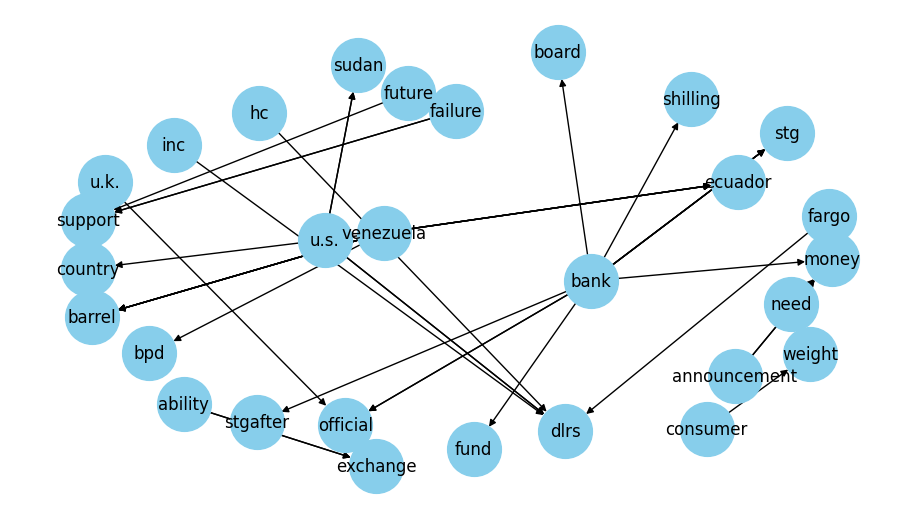

In [ ]:
import os

plt.figure(figsize=(9, 5))

pos = nx.fruchterman_reingold_layout(G, k=1.6) # k regulates the distance between nodes

nx.draw(G, with_labels=True, node_color='skyblue', node_size=1500, edge_cmap=plt.cm.Blues, pos = pos, font_size=12)

# plt.show()
# plt.savefig(os.path.join(".", "KnowledgeGraph.png"), dpi=300, format="png")
